In [1]:
import pandas as pd
import numpy as np
import random
# import ast
from pyfaidx import Fasta
from torch.utils.data import Dataset, DataLoader
import torch

In [2]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

In [3]:
# from model import SeqNN
from model_v2_compatible import SeqNN

In [4]:
def one_hot_encode_sequence(sequence_obj):
    # Convert pyfaidx.Sequence object to string
    sequence = str(sequence_obj).upper()
    
    # Define the mapping from bases to integers
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    valid_bases = list(base_to_int.keys())

    # Step 1: Convert sequence to integer encoding with random base for 'N'
    encoded_indices = []
    for base in sequence:
        if base in base_to_int:
            encoded_indices.append(base_to_int[base])
        else:
            random_base = random.choice(valid_bases)
            encoded_indices.append(base_to_int[random_base])

    # Step 2: One-hot encode the sequence
    encoded_sequence = np.array(encoded_indices)
    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    return one_hot_encoded

In [5]:
class GenomicSequenceDataset(Dataset):
    def __init__(self, coord_df, genome_fasta, transform_fn=None):
        self.coords = coord_df  # DataFrame with chrom, start, end
        self.genome = genome_fasta
        self.transform_fn = transform_fn  # Optional function to modify sequence

    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        TARGET_LEN = 1310720
        
        row = self.coords.iloc[idx]
        chrom, start, end = row["chrom1"], row["window_start"], row["window_end"]
        seq = self.genome[chrom][start:end].seq.upper()
        
        # Fix sequence length if needed
        if len(seq) != TARGET_LEN:
            seq = seq[:TARGET_LEN].ljust(TARGET_LEN, 'N')  # pad with Ns if needed
        
        # Apply transformation, e.g. permute a window
        if self.transform_fn is not None:
            seq = self.transform_fn(seq, row)  # Pass row in case you want loc info
        
        one_hot = one_hot_encode_sequence(seq)  # shape: (4, L)
        return torch.from_numpy(one_hot.copy())

In [6]:
def set_diag(matrix, value, k):
    """Set diagonal `k` of a matrix to `value`."""
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value


def from_upper_triu_batch(batch_vectors, matrix_len=512, num_diags=2):
    """Convert a batch of upper-triangular vectors into symmetric matrices with np.nan on diagonals."""
    if isinstance(batch_vectors, torch.Tensor):
        batch_vectors = batch_vectors.detach().cpu().numpy()

    batch_size = batch_vectors.shape[0]
    matrices = np.zeros((batch_size, matrix_len, matrix_len), dtype=np.float32)

    triu_indices = np.triu_indices(matrix_len, num_diags)

    for i in range(batch_size):
        matrices[i][triu_indices] = batch_vectors[i]
        # Mirror to lower triangle
        matrices[i] = matrices[i] + matrices[i].T

        # Set diagonals to np.nan
        for k in range(-num_diags + 1, num_diags):
            set_diag(matrices[i], np.nan, k)

    return matrices  # shape: [B, 512, 512]   

In [7]:
flame_df_path = "/scratch1/smaruj/stripepy_stripes/selected_stripes.tsv"

In [8]:
flame_df = pd.read_csv(flame_df_path, sep="\t")[:18]

In [ ]:
len(flame_df)

In [9]:
RES = 8192

flame_df["y_bins"] = flame_df["y_length"] // RES
flame_df["x_bins"] = flame_df["x_length"] // RES

In [10]:
fasta_file = "/project/fudenber_735/genomes/mm10/mm10.fa"
genome = Fasta(fasta_file)

In [11]:
orig_dataset = GenomicSequenceDataset(flame_df, genome)

In [12]:
orig_loader = DataLoader(orig_dataset, batch_size=16, shuffle=False)

In [13]:
# --- Load model ---
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = SeqNN()
model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_finetuned_correctly.pt", map_location=device))
model.eval()

/tmp/SLURM_1397284/ipykernel_1406568/2795485947.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
flame_df

,chrom1,start1,end1,chrom2,start2,end2,rel_change,frac_missing_bbox_pm5bins_bins,x_length,y_length,orientation,midpoint,window_start,window_end,y_bins,x_bins
0,chr1,3121152,4136960,chr1,3096576,3153920,20.008292,0.0,1015808,57344,horizontal,3121152,2465792,3776512,7,124
1,chr1,3178496,4341760,chr1,3162112,3194880,31.519521,0.0,1163264,32768,horizontal,3178496,2523136,3833856,4,142
2,chr1,3244032,3694592,chr1,3244032,3260416,29.272392,0.0,450560,16384,horizontal,3244032,2588672,3899392,2,55
3,chr1,3801088,3850240,chr1,3170304,3833856,17.663422,0.0,49152,663552,vertical,3833856,3178496,4489216,81,6
4,chr1,4005888,4055040,chr1,3358720,4030464,24.861986,0.0,49152,671744,vertical,4030464,3375104,4685824,82,6
5,chr1,4055040,4079616,chr1,3088384,4055040,25.692666,0.0,24576,966656,vertical,4055040,3399680,4710400,118,3
6,chr1,4096000,4431872,chr1,4087808,4112384,22.091149,0.0,335872,24576,horizontal,4096000,3440640,4751360,3,41
7,chr1,4120576,4161536,chr1,3678208,4136960,16.580905,0.0,40960,458752,vertical,4136960,3481600,4792320,56,5
8,chr1,4767744,5914624,chr1,4734976,4800512,22.467417,0.0,1146880,65536,horizontal,4767744,4112384,5423104,8,140
9,chr1,5013504,6209536,chr1,4997120,5038080,20.256242,0.0,1196032,40960,horizontal,5013504,4358144,5668864,5,146


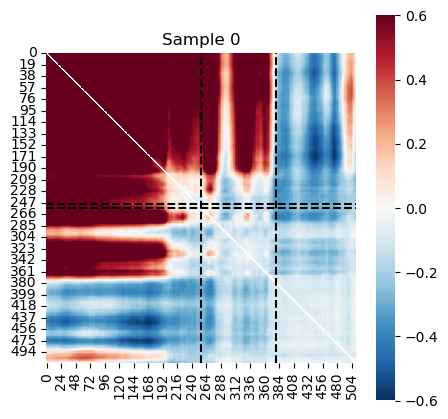

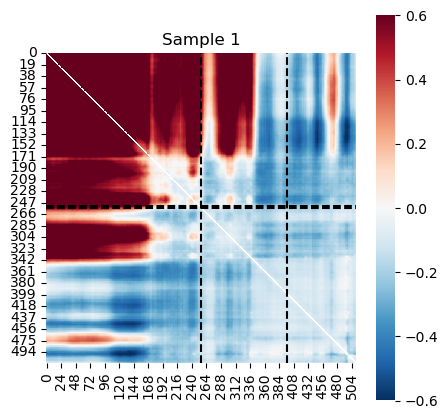

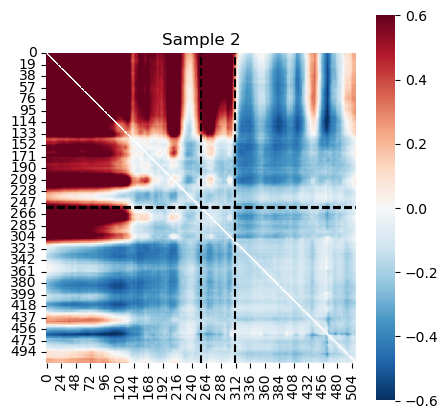

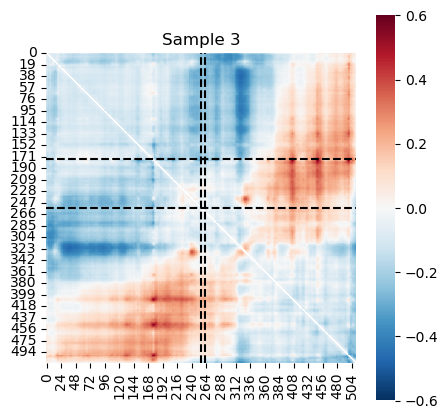

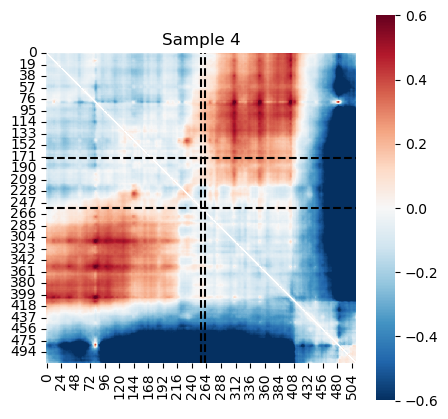

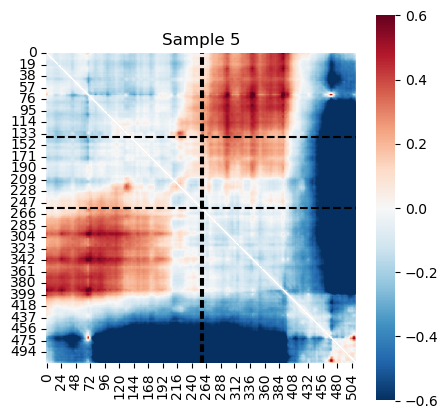

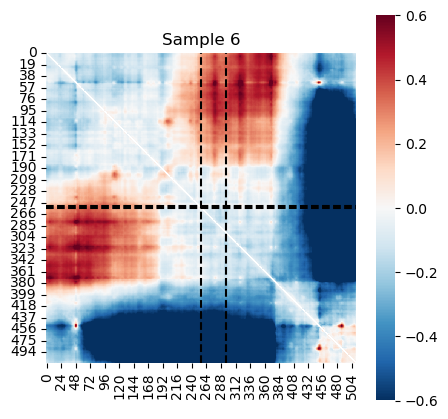

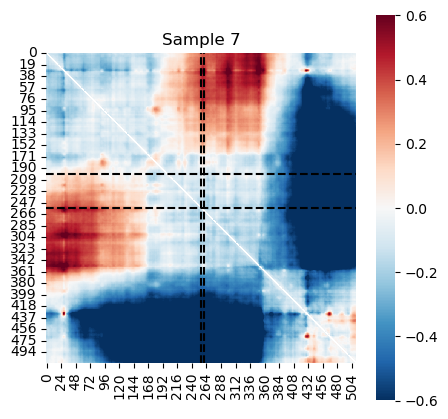

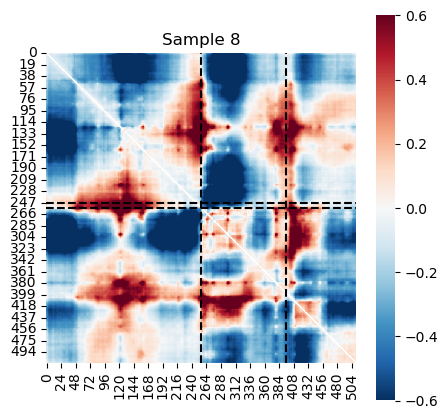

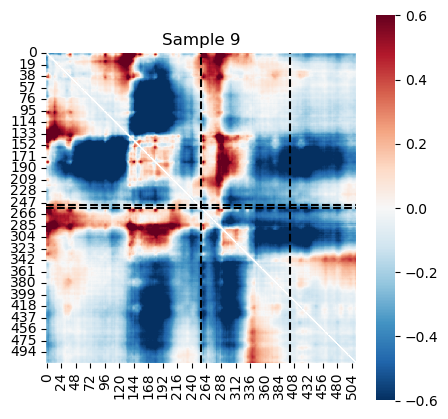

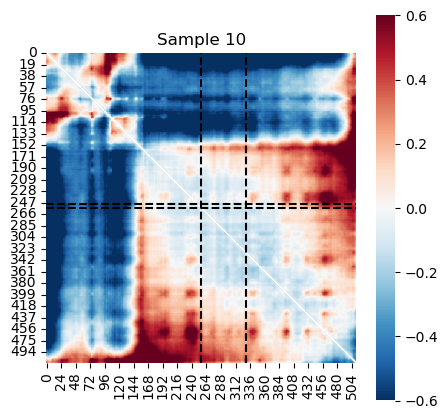

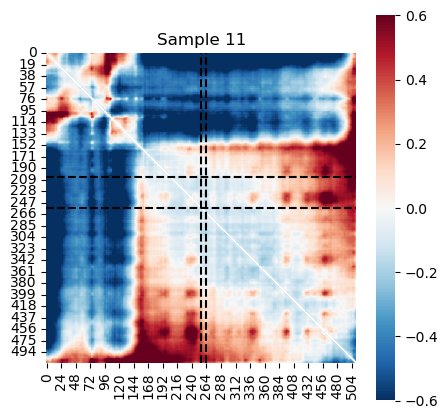

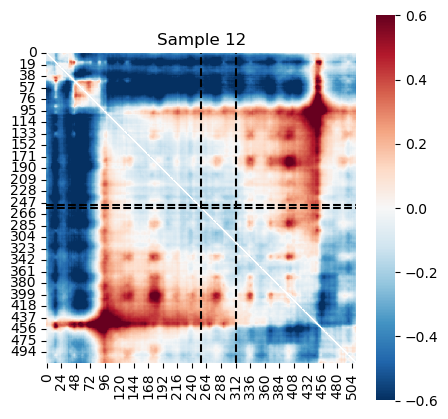

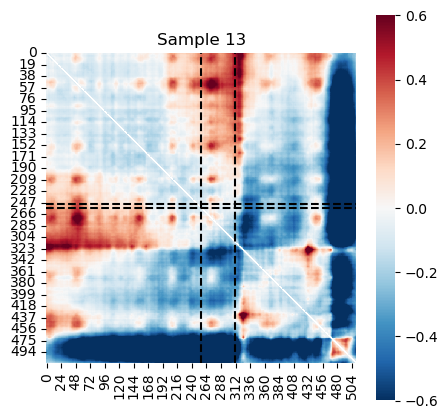

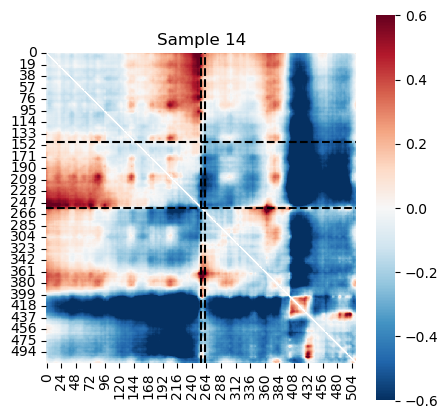

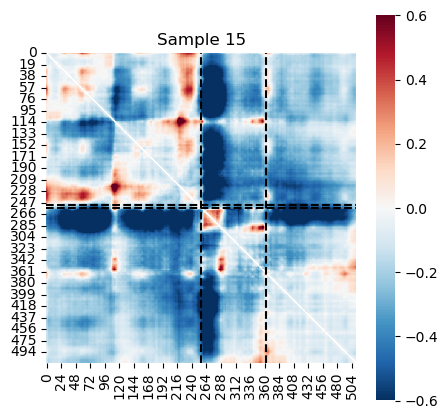

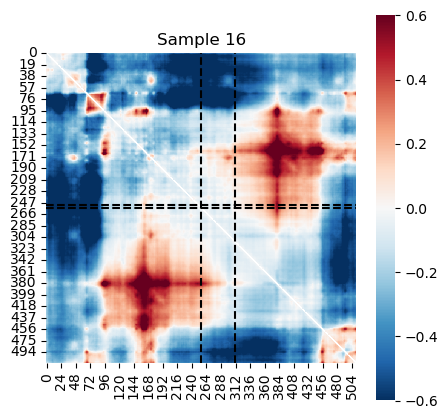

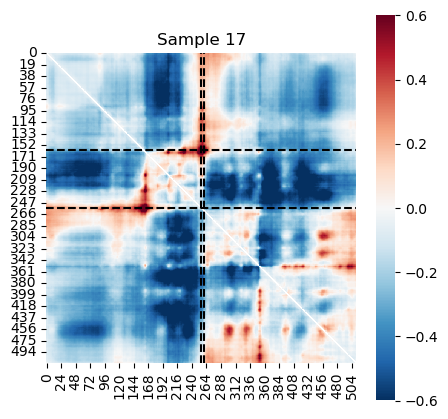

In [16]:
map_midbin = 256

# --- Inference and metrics ---
results = []

start_idx = 0

with torch.no_grad():
    for orig_batch in orig_loader:
        orig_preds = model(orig_batch.to(device)).cpu()
        og_maps = from_upper_triu_batch(orig_preds)
        
        this_batch_size = og_maps.shape[0]
        
        for i in range(this_batch_size):
            abs_i = start_idx + i
            
            x_end = map_midbin + flame_df["x_bins"][abs_i]
            y_start = map_midbin - flame_df["y_bins"][abs_i]
            
            flame_mean = np.nanmean(og_maps[i, map_midbin:x_end, y_start:map_midbin])
            results.append(flame_mean)

            # fig, ax = plt.subplots(figsize=(5, 5))
            # sns.heatmap(og_maps[i], cmap="RdBu_r", center=0, square=True, ax=ax, vmin=-0.6, vmax=0.6)

            # # Draw vertical and horizontal lines at dot_r and dot_c
            # ax.axhline(map_midbin, color='black', linestyle='--')
            # ax.axhline(y_start, color='black', linestyle='--')
            # ax.axvline(x_end, color='black', linestyle='--')
            # ax.axvline(map_midbin, color='black', linestyle='--')
            
            # ax.set_title(f"Sample {abs_i}")
            # plt.show()
            
        start_idx += this_batch_size
        
flame_df["flame_strength"] = results

In [17]:
flame_df

,chrom1,start1,end1,chrom2,start2,end2,rel_change,frac_missing_bbox_pm5bins_bins,x_length,y_length,orientation,midpoint,window_start,window_end,y_bins,x_bins,flame_strength
0,chr1,3121152,4136960,chr1,3096576,3153920,20.008292,0.0,1015808,57344,horizontal,3121152,2465792,3776512,7,124,-0.135729
1,chr1,3178496,4341760,chr1,3162112,3194880,31.519521,0.0,1163264,32768,horizontal,3178496,2523136,3833856,4,142,-0.147722
2,chr1,3244032,3694592,chr1,3244032,3260416,29.272392,0.0,450560,16384,horizontal,3244032,2588672,3899392,2,55,-0.131512
3,chr1,3801088,3850240,chr1,3170304,3833856,17.663422,0.0,49152,663552,vertical,3833856,3178496,4489216,81,6,-0.043818
4,chr1,4005888,4055040,chr1,3358720,4030464,24.861986,0.0,49152,671744,vertical,4030464,3375104,4685824,82,6,0.003917
5,chr1,4055040,4079616,chr1,3088384,4055040,25.692666,0.0,24576,966656,vertical,4055040,3399680,4710400,118,3,0.073791
6,chr1,4096000,4431872,chr1,4087808,4112384,22.091149,0.0,335872,24576,horizontal,4096000,3440640,4751360,3,41,-0.075075
7,chr1,4120576,4161536,chr1,3678208,4136960,16.580905,0.0,40960,458752,vertical,4136960,3481600,4792320,56,5,-0.093041
8,chr1,4767744,5914624,chr1,4734976,4800512,22.467417,0.0,1146880,65536,horizontal,4767744,4112384,5423104,8,140,-0.243148
9,chr1,5013504,6209536,chr1,4997120,5038080,20.256242,0.0,1196032,40960,horizontal,5013504,4358144,5668864,5,146,-0.319554
